# 03b — Tiny Audio Spectrogram Transformer · Alertreck Threat Detection

**Model:** Vision Transformer (ViT-Tiny) fine-tuned on 128-bin log-mel spectrograms  
**Architecture:** `vit_tiny_patch16_224` pretrained on ImageNet-21k, adapted to 1-channel audio  
**Classes:** 7 fine-grained (background_animals, background_wind_rain, threat_chainsaw, threat_dog, threat_gunshot, threat_human, threat_vehicle)  
**Data:** `data/processed/mel/` shards from Stage 2 preprocessing  
**Platform:** Kaggle T4 GPU

---

## Key differences from CNN (03a)
| | CNN (03a) | Tiny-AST (03b) |
|---|---|---|
| Architecture | 4-block ConvNet from scratch | ViT-Tiny pretrained (ImageNet) |
| Input size | (1, 128, 259) | (1, 224, 224) resized |
| Parameters | ~1.2 M | ~5.7 M |
| Training | from scratch | fine-tuning |
| Scheduler | ReduceLROnPlateau | CosineAnnealing + warmup |

## Kaggle Setup
Add your `alertreck-mel` dataset via **Add Data** before running.

In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import seaborn as sns

# Install timm if not present
try:
    import timm
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'timm', '-q'])
    import timm

print(f'PyTorch  {torch.__version__}')
print(f'timm     {timm.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   {device}')
if device.type == 'cuda':
    print(f'GPU      {torch.cuda.get_device_name(0)}')
    print(f'VRAM     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  2.10.0+cu128
timm     1.0.25
Device   cuda
GPU      Tesla T4
VRAM     15.6 GB


In [2]:
# ── 2. Config ─────────────────────────────────────────────────────────────────
def _find_data_root() -> Path:
    for p in Path('/kaggle/input').rglob('train'):
        if p.is_dir():
            return p.parent
    return Path('/kaggle/input/datasets/orpheusmanga/alertreck-mel/mel')

CFG = {
    # paths
    'data_root':  _find_data_root(),
    'output_dir': Path('/kaggle/working/models/tiny_ast'),

    # model
    'model_name':  'vit_tiny_patch16_224',
    'pretrained':  True,
    'n_classes':   7,
    'img_size':    224,          # ViT expects 224×224

    # training
    'seed':        42,
    'epochs':      30,
    'batch_size':  64,           # smaller than CNN — ViT uses more memory
    'lr':          3e-4,         # fine-tuning LR
    'weight_decay':1e-2,
    'warmup_epochs': 3,
    'patience':    7,

    # labels
    'label_names': [
        'background_animals',
        'background_wind_rain',
        'threat_chainsaw',
        'threat_dog',
        'threat_gunshot',
        'threat_human',
        'threat_vehicle',
    ],
}

CFG['output_dir'].mkdir(parents=True, exist_ok=True)
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if device.type == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])

print('Config OK')
print(f"Data root : {CFG['data_root']}")
print(f"Output    : {CFG['output_dir']}")
print(f"Model     : {CFG['model_name']}  pretrained={CFG['pretrained']}")

Config OK
Data root : /kaggle/input/datasets/orpheusmanga/alertreck-mel/mel
Output    : /kaggle/working/models/tiny_ast
Model     : vit_tiny_patch16_224  pretrained=True


In [3]:
# ── 3. Dataset ────────────────────────────────────────────────────────────────
class ShardDataset(Dataset):
    """
    Loads mel spectrogram shards and resizes to (1, 224, 224) for ViT input.
    Normalises from raw dB range [-80, 0] → [0, 1] → ImageNet-style [-1, 1].
    """
    IMG_MEAN = 0.5
    IMG_STD  = 0.5

    def __init__(self, shard_dir: Path, img_size: int = 224, augment: bool = False):
        shards = sorted(shard_dir.glob('*.npz'))
        assert shards, f'No shards found in {shard_dir}'

        xs, ys = [], []
        for s in tqdm(shards, desc=f'Loading {shard_dir.name}'):
            d = np.load(s)
            xs.append(d['X'])
            ys.append(d['y'].astype(np.int64))

        self.X       = np.concatenate(xs, axis=0)   # (N, 128, 259)
        self.y       = np.concatenate(ys, axis=0)
        self.img_size = img_size
        self.augment  = augment
        print(f'  {shard_dir.name}: {len(self.X):,} samples')

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].copy()          # (128, 259)  float32, dB values

        # SpecAugment-lite (train only)
        if self.augment:
            f0 = random.randint(0, x.shape[0] - 15)
            x[f0:f0 + random.randint(0, 15), :] = x.min()
            t0 = random.randint(0, x.shape[1] - 30)
            x[:, t0:t0 + random.randint(0, 30)] = x.min()

        # dB [-80, 0] → [0, 1]
        x = (x + 80.0) / 80.0
        x = np.clip(x, 0.0, 1.0)

        # Add channel dim, convert to tensor → (1, 128, 259)
        x = torch.from_numpy(x).unsqueeze(0)

        # Resize to (1, 224, 224) using bilinear interpolation
        x = F.interpolate(
            x.unsqueeze(0),
            size=(self.img_size, self.img_size),
            mode='bilinear',
            align_corners=False,
        ).squeeze(0)

        # Normalise to [-1, 1] (ImageNet-style, single channel)
        x = (x - self.IMG_MEAN) / self.IMG_STD

        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


data_root = CFG['data_root']
train_ds = ShardDataset(data_root / 'train', img_size=CFG['img_size'], augment=True)
val_ds   = ShardDataset(data_root / 'val',   img_size=CFG['img_size'], augment=False)
test_ds  = ShardDataset(data_root / 'test',  img_size=CFG['img_size'], augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=4, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

# Sanity check shape
xb, yb = next(iter(train_loader))
print(f'Batch shape: {tuple(xb.shape)}  labels: {tuple(yb.shape)}')

Loading train:   0%|          | 0/72 [00:00<?, ?it/s]

  train: 71,624 samples


Loading val:   0%|          | 0/4 [00:00<?, ?it/s]

  val: 3,411 samples


Loading test:   0%|          | 0/4 [00:00<?, ?it/s]

  test: 3,411 samples

Train batches: 1120 | Val: 54 | Test: 54
Batch shape: (64, 1, 224, 224)  labels: (64,)


In [4]:
# ── 4. Class weights ──────────────────────────────────────────────────────────
counts  = np.bincount(train_ds.y, minlength=CFG['n_classes']).astype(np.float32)
weights = counts.sum() / (CFG['n_classes'] * counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:')
for i, (name, w) in enumerate(zip(CFG['label_names'], weights)):
    print(f'  [{i}] {name:<26}  n={int(counts[i]):>6}  weight={w:.3f}')

Class weights:
  [0] background_animals          n= 24234  weight=0.422
  [1] background_wind_rain        n=  5712  weight=1.791
  [2] threat_chainsaw             n= 10710  weight=0.955
  [3] threat_dog                  n=  4536  weight=2.256
  [4] threat_gunshot              n= 10080  weight=1.015
  [5] threat_human                n= 11816  weight=0.866
  [6] threat_vehicle              n=  4536  weight=2.256


In [5]:
# ── 5. Model — ViT-Tiny fine-tune ─────────────────────────────────────────────
model = timm.create_model(
    CFG['model_name'],
    pretrained=CFG['pretrained'],
    num_classes=CFG['n_classes'],
    in_chans=1,          # single-channel mel spectrogram
)
model = model.to(device)

n_params     = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_params_all = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters : {n_params:,}')
print(f'Total parameters     : {n_params_all:,}')

# Sanity-check forward pass
dummy = torch.randn(2, 1, CFG['img_size'], CFG['img_size']).to(device)
out   = model(dummy)
print(f'Forward pass OK: {tuple(dummy.shape)} → {tuple(out.shape)}')

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Trainable parameters : 5,427,463
Total parameters     : 5,427,463
Forward pass OK: (2, 1, 224, 224) → (2, 7)


In [6]:
# ── 6. Loss, optimiser, scheduler ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay'],
)

total_steps  = CFG['epochs'] * len(train_loader)
warmup_steps = CFG['warmup_epochs'] * len(train_loader)

def lr_lambda(step: int) -> float:
    """Linear warmup then cosine decay."""
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f'Scheduler: linear warmup ({CFG["warmup_epochs"]} epochs) + cosine decay')
print(f'Total steps: {total_steps}  |  Warmup steps: {warmup_steps}')

Scheduler: linear warmup (3 epochs) + cosine decay
Total steps: 33600  |  Warmup steps: 3360


In [7]:
# ── 7. Training utilities ─────────────────────────────────────────────────────
def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            n          += len(y)

    return total_loss / n, correct / n


def predict_all(loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds.append(model(X.to(device)).argmax(1).cpu())
            labels.append(y)
    return torch.cat(preds).numpy(), torch.cat(labels).numpy()

In [8]:
# ── 8. Training loop ──────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_loss    = float('inf')
patience_counter = 0
best_model_path  = CFG['output_dir'] / 'best_model.pt'

print(f"Training up to {CFG['epochs']} epochs  (early stop patience={CFG['patience']})\n")
t0 = time.time()

for epoch in range(1, CFG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(val_loader,   training=False)

    current_lr = scheduler.get_last_lr()[0]
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['lr'].append(current_lr)

    elapsed = (time.time() - t0) / 60
    print(f'Epoch {epoch:02d}/{CFG["epochs"]}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'val_loss={va_loss:.4f}  val_acc={va_acc:.4f}  '
          f'lr={current_lr:.2e}  [{elapsed:.1f} min]')

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_counter = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss':    va_loss,
            'val_acc':     va_acc,
            'cfg':         {k: str(v) for k, v in CFG.items()},
        }, best_model_path)
        print(f'  ✓ best model saved (val_loss={va_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f'\nEarly stopping at epoch {epoch}')
            break

print(f'\nTraining complete in {(time.time()-t0)/60:.1f} min')
print(f'Best val loss: {best_val_loss:.4f}')

Training up to 30 epochs  (early stop patience=7)

Epoch 01/30  train_loss=0.4401  train_acc=0.8298  val_loss=0.1750  val_acc=0.9546  lr=1.00e-04  [4.5 min]
  ✓ best model saved (val_loss=0.1750)
Epoch 02/30  train_loss=0.1639  train_acc=0.9402  val_loss=0.2302  val_acc=0.9402  lr=2.00e-04  [9.1 min]
Epoch 03/30  train_loss=0.1464  train_acc=0.9477  val_loss=0.1412  val_acc=0.9578  lr=3.00e-04  [13.7 min]
  ✓ best model saved (val_loss=0.1412)
Epoch 04/30  train_loss=0.1236  train_acc=0.9561  val_loss=0.1317  val_acc=0.9622  lr=2.99e-04  [18.3 min]
  ✓ best model saved (val_loss=0.1317)
Epoch 05/30  train_loss=0.0956  train_acc=0.9681  val_loss=0.1138  val_acc=0.9745  lr=2.96e-04  [22.9 min]
  ✓ best model saved (val_loss=0.1138)
Epoch 06/30  train_loss=0.0775  train_acc=0.9732  val_loss=0.1686  val_acc=0.9692  lr=2.91e-04  [27.5 min]
Epoch 07/30  train_loss=0.0664  train_acc=0.9771  val_loss=0.1499  val_acc=0.9645  lr=2.84e-04  [32.1 min]
Epoch 08/30  train_loss=0.0598  train_acc=0.97

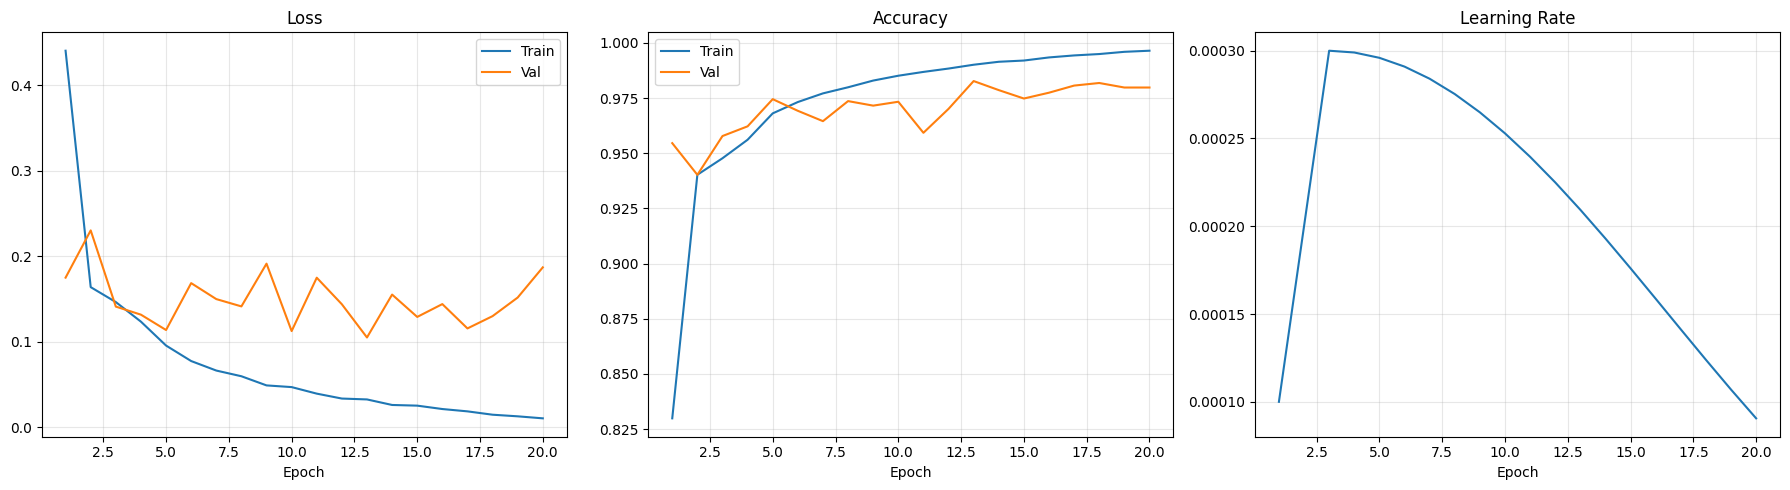

In [9]:
# ── 9. Training curves ────────────────────────────────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_ran, history['train_loss'], label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history['lr'])
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'training_curves.png', dpi=150)
plt.show()

In [10]:
# ── 10. Load best model & evaluate on test set ────────────────────────────────
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.4f}, val_acc={checkpoint['val_acc']:.4f})")

test_preds, test_labels = predict_all(test_loader)
test_acc = (test_preds == test_labels).mean()
test_f1  = f1_score(test_labels, test_preds, average='macro')

print(f'\nTest accuracy : {test_acc:.4f}')
print(f'Test macro-F1 : {test_f1:.4f}')

Loaded best model from epoch 13 (val_loss=0.1051, val_acc=0.9827)

Test accuracy : 0.9789
Test macro-F1 : 0.9735


In [11]:
# ── 11. Per-class classification report ───────────────────────────────────────
print(classification_report(test_labels, test_preds,
                             target_names=CFG['label_names'], digits=4))

                      precision    recall  f1-score   support

  background_animals     0.9799    0.9731    0.9765      1154
background_wind_rain     0.9470    0.9853    0.9658       272
     threat_chainsaw     0.9880    0.9706    0.9792       510
          threat_dog     0.8952    0.9491    0.9213       216
      threat_gunshot     1.0000    1.0000    1.0000       480
        threat_human     0.9947    0.9964    0.9956       563
      threat_vehicle     0.9952    0.9583    0.9764       216

            accuracy                         0.9789      3411
           macro avg     0.9714    0.9761    0.9735      3411
        weighted avg     0.9794    0.9789    0.9790      3411



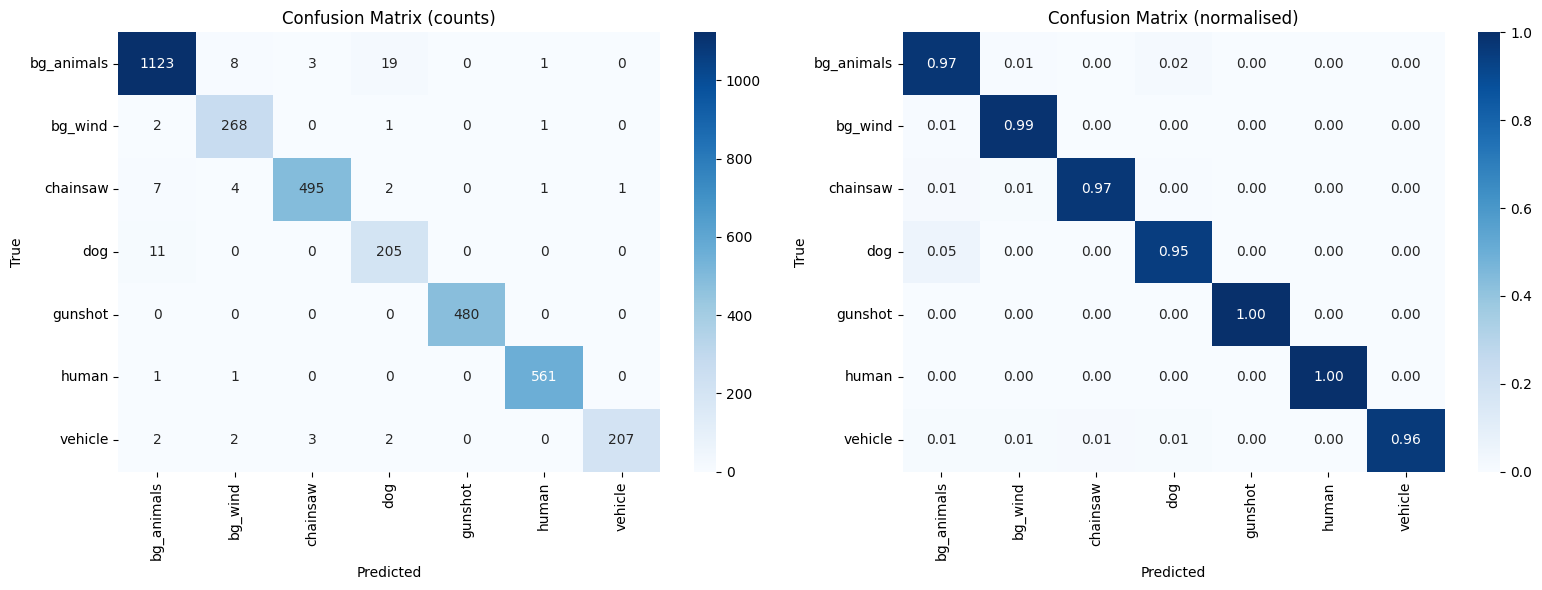

In [12]:
# ── 12. Confusion matrix ──────────────────────────────────────────────────────
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

short_names = ['bg_animals', 'bg_wind', 'chainsaw', 'dog', 'gunshot', 'human', 'vehicle']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=short_names, yticklabels=short_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'confusion_matrix.png', dpi=150)
plt.show()

In [13]:
# ── 13. Save results JSON ─────────────────────────────────────────────────────
results = {
    'model':          'Tiny Audio Spectrogram Transformer (ViT-Tiny)',
    'timm_model':     CFG['model_name'],
    'pretrained':     CFG['pretrained'],
    'best_epoch':     int(checkpoint['epoch']),
    'val_loss':       float(checkpoint['val_loss']),
    'val_acc':        float(checkpoint['val_acc']),
    'test_acc':       float(test_acc),
    'test_macro_f1':  float(test_f1),
    'per_class_f1': {
        name: float(f1_score(test_labels == i, test_preds == i, average='binary'))
        for i, name in enumerate(CFG['label_names'])
    },
    'n_params': n_params,
    'history':  history,
}

results_path = CFG['output_dir'] / 'results.json'
results_path.write_text(json.dumps(results, indent=2))
print(f'Results saved → {results_path}')

print('\n=== Summary ===')
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test macro-F1 : {test_f1:.4f}")
print(f"Parameters    : {n_params:,}")
print(f"Best epoch    : {checkpoint['epoch']}")

# ── Comparison reminder ───────────────────────────────────────────────────────
print('\n=== Model Comparison (so far) ===')
cnn_path = Path('/kaggle/working/models/cnn/results.json')
if cnn_path.exists():
    cnn = json.loads(cnn_path.read_text())
    print(f"  CNN from scratch : acc={cnn['test_acc']:.4f}  f1={cnn['test_macro_f1']:.4f}  params={cnn['n_params']:,}")
print(f"  Tiny-AST (ViT)   : acc={test_acc:.4f}  f1={test_f1:.4f}  params={n_params:,}")

Results saved → /kaggle/working/models/tiny_ast/results.json

=== Summary ===
Test accuracy : 0.9789
Test macro-F1 : 0.9735
Parameters    : 5,427,463
Best epoch    : 13

=== Model Comparison (so far) ===
  Tiny-AST (ViT)   : acc=0.9789  f1=0.9735  params=5,427,463
